In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL2phY2tsaS9KU0MzNzAtUHJvamVjdA=='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/importlib/_bootstrap.py": 1764955392.0, "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/importlib/_bootstrap_external.py": 1764955392.0, "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/zipimport.py": 1764955391.0, "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/codecs.py": 1764955391.0, "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/encodings/aliases.py": 1764955391.0, "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/encodings/__init__.py": 1764955391.0, "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/encodings/utf_8.py": 1764955391.0, "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/abc.py": 1764955391.0, "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/stat.py": 1764955391.0, "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/_collections_abc.py": 176495

In [2]:
import datetime as dt
import json
import os
import time

import numpy as np
import pandas as pd
import requests

import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *

from dotenv import load_dotenv

import statsmodels.api as sm
from scipy.stats import pearsonr, ttest_ind, friedmanchisquare

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    auc,
    roc_auc_score,
    roc_curve
)

from xgboost import XGBClassifier, XGBRegressor

import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
# load_dotenv()
def get_fred_series(series_id):
    
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": "adc89f75fa31f7c985334862e25961c7",
        "file_type": "json"
    }
    
    r = requests.get(url, params=params)
    data = r.json()["observations"]
    
    df = pd.DataFrame(data)
    df = df[["date","value"]]
    
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.set_index("date")

    return df

In [4]:
def yahoo_chart_history(symbol, period1, period2, interval="1d"):
    url = f"https://query1.finance.yahoo.com/v8/finance/chart/{symbol}"
    params = {
        "period1": period1,
        "period2": period2,
        "interval": interval,
        "includeAdjustedClose": "true"
    }
    headers = {"User-Agent": "JSC370 Midterm Project - Data Collection"}

    r = requests.get(url, params=params, headers=headers, timeout=30)
    r.raise_for_status()

    payload = r.json()
    result = payload["chart"]["result"][0]

    ts = result["timestamp"]
    q = result["indicators"]["quote"][0]
    adj = result["indicators"]["adjclose"][0]["adjclose"]

    out = pd.DataFrame({
        "date": pd.to_datetime(ts, unit="s"),
        "open": q["open"],
        "high": q["high"],
        "low": q["low"],
        "close": q["close"],
        "adj_close": adj,
        "volume": q["volume"]
    })

    out['date'] = out['date'].dt.floor("D")

    return out.dropna(subset=["date", "close"]).sort_values("date").reset_index(drop=True)

In [5]:
#| label: download-yahoo-data

start = dt.datetime(1980,1,1)
end = dt.datetime(2026,3,1)
period1 = int(start.timestamp())
period2 = int(end.timestamp())

sp500 = yahoo_chart_history("^GSPC", period1, period2)
downjones = yahoo_chart_history("^DJI", period1, period2)  # Dow Jones Industrial Average
yield10y = yahoo_chart_history("^TNX", period1, period2)   # 10-year Treasury
yield1y = yahoo_chart_history("^IRX", period1, period2)   # 1-year Treasury
usd_index = yahoo_chart_history("DX-Y.NYB", period1, period2)  # US Dollar Index
vix_level = yahoo_chart_history("^VIX", period1, period2)  # CBOE Volatility Index
oil_price = yahoo_chart_history("CL=F", period1, period2)  # Crude Oil Price

In [6]:
#| label: download-fred-data

fed_funds_rate = get_fred_series("FEDFUNDS")  # Federal Funds Rate
inflation_rate = get_fred_series("CPIAUCSL")  # Consumer Price Index for All Urban Consumers: All Items
unemployment_rate = get_fred_series("UNRATE")  # Unemployment Rate
industrial_production_growth = get_fred_series("INDPRO")  # Industrial Production Index
consumer_sentiment = get_fred_series("UMCSENT")  # University of Michigan: Consumer Sentiment

baa = get_fred_series("BAA")
treasury10 = get_fred_series("DGS10")
credit_spread = (baa - treasury10).dropna()

In [7]:
sp500 = sp500[["date", "close"]].rename(columns={"close": "S&P 500"})
downjones = downjones[["date", "close"]].rename(columns={"close": "Dow Jones"})
yield10y = yield10y[["date", "close"]].rename(columns={"close": "10Y Yield"})
yield1y = yield1y[["date", "close"]].rename(columns={"close": "1Y Yield"})
usd_index = usd_index[["date", "close"]].rename(columns={"close": "USD Index"})
vix_level = vix_level[["date", "close"]].rename(columns={"close": "Volatility Index"})
oil_price = oil_price[["date", "close"]].rename(columns={"close": "Oil Price"})

In [8]:
fed_funds_rate = fed_funds_rate.rename(columns={"value": "fed_funds_rate"})
inflation_rate = inflation_rate.rename(columns={"value": "inflation_rate"})
unemployment_rate = unemployment_rate.rename(columns={"value": "unemployment_rate"})
industrial_production_growth = industrial_production_growth.rename(columns={"value": "industrial_production"})
credit_spread = credit_spread.rename(columns={"value": "credit_spread"})
consumer_sentiment = consumer_sentiment.rename(columns={"value": "consumer_sentiment"})

def fred_to_daily(df):
    df_daily = df.resample("D").ffill()
    return df_daily

fed_funds_rate = fred_to_daily(fed_funds_rate)
inflation_rate = fred_to_daily(inflation_rate)
unemployment_rate = fred_to_daily(unemployment_rate)
industrial_production_growth = fred_to_daily(industrial_production_growth)
credit_spread = fred_to_daily(credit_spread)
consumer_sentiment = fred_to_daily(consumer_sentiment)

In [9]:
sp500.set_index("date", inplace=True)
downjones.set_index("date", inplace=True)
yield10y.set_index("date", inplace=True)
yield1y.set_index("date", inplace=True)
usd_index.set_index("date", inplace=True)
vix_level.set_index("date", inplace=True)
oil_price.set_index("date", inplace=True)

market = pd.concat([sp500, downjones, yield10y, yield1y, usd_index, oil_price, vix_level, fed_funds_rate, inflation_rate, unemployment_rate, industrial_production_growth, credit_spread, consumer_sentiment], axis=1).dropna()

market['sp500_return'] = market['S&P 500'].pct_change()
market['downjones_return'] = market['Dow Jones'].pct_change()
market.reset_index(inplace=True)

In [10]:
# Feature Engineering

model_df = market.copy()

# Create multi-horizon targets
horizons = [1, 5, 20]

for h in horizons:
    # Main prediction targets
    model_df[f"sp500_return_t{h}"] = model_df["S&P 500"].pct_change(h).shift(-h)
    
    # direction target: 1 if future return > 0, else 0
    model_df[f"sp500_up_t{h}"] = (model_df[f"sp500_return_t{h}"] > 0).astype(int)

model_df = model_df.dropna().reset_index(drop=True)

# Base predictors from current dataset
base_predictors = [
    "Volatility Index",
    "10Y Yield",
    "1Y Yield",
    "USD Index",
    "Oil Price",
    "fed_funds_rate",
    "inflation_rate",
    "unemployment_rate",
    "industrial_production",
    "credit_spread",
    "consumer_sentiment"
]

# 3. Multiple lag features
lags = [1, 3, 5, 10]

for var in base_predictors:
    for lag in lags:
        model_df[f"{var}_lag{lag}"] = model_df[var].shift(lag)

# 4. Rolling average features
rolling_windows = [5, 10, 20]

for var in ["Volatility Index", "10Y Yield", "1Y Yield", "USD Index", "Oil Price", "credit_spread"]:
    for window in rolling_windows:
        model_df[f"{var}_rollmean{window}"] = model_df[var].rolling(window).mean()

# 5. Rolling volatility of stock returns
for window in rolling_windows:
    model_df[f"sp500_volatility{window}"] = model_df["sp500_return"].rolling(window).std()
    model_df[f"downjones_volatility{window}"] = model_df["downjones_return"].rolling(window).std()

# 6. Momentum features
for window in rolling_windows:
    model_df[f"sp500_momentum{window}"] = model_df["sp500_return"].rolling(window).sum()
    model_df[f"downjones_momentum{window}"] = model_df["downjones_return"].rolling(window).sum()

# 7. Rate-of-change features
for var in ["Volatility Index", "10Y Yield", "1Y Yield", "USD Index", "Oil Price", "credit_spread"]:
    model_df[f"{var}_change1"] = model_df[var].diff(1)
    model_df[f"{var}_change5"] = model_df[var].diff(5)

# 8. Yield spread feature
model_df["yield_spread_10y_1y"] = model_df["10Y Yield"] - model_df["1Y Yield"]
model_df["yield_spread_10y_1y_lag1"] = model_df["yield_spread_10y_1y"].shift(1)

# Drop missing values created by lags, rolling windows, and future target
model_df = model_df.dropna().reset_index(drop=True)

model_df.shape

(6273, 110)

In [11]:
exclude_cols = [
    "date",
    "S&P 500",
    "Dow Jones",
    "sp500_return",
    "downjones_return"
]

target_cols = []

for h in horizons:
    target_cols.append(f"sp500_return_t{h}")
    target_cols.append(f"sp500_up_t{h}")

feature_cols = [
    col for col in model_df.columns 
    if col not in exclude_cols + target_cols
]

In [12]:
model_df = model_df.sort_values("date").reset_index(drop=True)

n = len(model_df)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)

train = model_df.iloc[:train_end].copy()
valid = model_df.iloc[train_end:valid_end].copy()
test = model_df.iloc[valid_end:].copy()

X_train = train[feature_cols]
X_valid = valid[feature_cols]
X_test = test[feature_cols]

print("Train shape:", X_train.shape)
print("Validation shape:", X_valid.shape)
print("Test shape:", X_test.shape)

print("\nDate ranges:")
print("Train:", train["date"].min(), "to", train["date"].max())
print("Valid:", valid["date"].min(), "to", valid["date"].max())
print("Test :", test["date"].min(),  "to", test["date"].max())

Train shape: (4391, 99)
Validation shape: (941, 99)
Test shape: (941, 99)

Date ranges:
Train: 2000-09-21 00:00:00 to 2018-04-05 00:00:00
Valid: 2018-04-06 00:00:00 to 2021-12-29 00:00:00
Test : 2021-12-30 00:00:00 to 2025-09-30 00:00:00


In [13]:
# Evaluation helper function
N_TRIALS = 25
OPTUNA_JOBS = 4   
random_state = 370

def evaluate_regression(model_name, horizon, y_true, y_pred):
    return {
        "Horizon": horizon,
        "Model": model_name,
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }


def evaluate_classification(model_name, horizon, y_true, y_pred, y_prob=None):
    out = {
        "Horizon": horizon,
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred)
    }
    
    if y_prob is not None:
        out["ROC_AUC"] = roc_auc_score(y_true, y_prob)
    
    return out

In [14]:
def tune_ridge(X_train, y_train, X_valid, y_valid):
    def objective(trial):
        alpha = trial.suggest_float("alpha", 1e-5, 100, log=True)

        model = Pipeline([
            ("scale", StandardScaler()),
            ("model", Ridge(alpha=alpha))
        ])

        model.fit(X_train, y_train)
        pred = model.predict(X_valid)

        return np.sqrt(mean_squared_error(y_valid, pred))

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=N_TRIALS, n_jobs=OPTUNA_JOBS)

    return study.best_params


def tune_lasso(X_train, y_train, X_valid, y_valid):
    def objective(trial):
        alpha = trial.suggest_float("alpha", 1e-5, 1e-1, log=True)

        model = Pipeline([
            ("scale", StandardScaler()),
            ("model", Lasso(alpha=alpha, max_iter=10000))
        ])

        model.fit(X_train, y_train)
        pred = model.predict(X_valid)

        return np.sqrt(mean_squared_error(y_valid, pred))

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=N_TRIALS, n_jobs=OPTUNA_JOBS)

    return study.best_params


def tune_rf_reg(X_train, y_train, X_valid, y_valid):
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 2, 20),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            "random_state": random_state,
            "n_jobs": 1
        }

        model = RandomForestRegressor(**params)
        model.fit(X_train, y_train)
        pred = model.predict(X_valid)

        return np.sqrt(mean_squared_error(y_valid, pred))

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=N_TRIALS, n_jobs=OPTUNA_JOBS)

    return study.best_params


def tune_xgb_reg(X_train, y_train, X_valid, y_valid):

    def objective(trial):

        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 800),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
            "max_depth": trial.suggest_int("max_depth", 2, 8),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "gamma": trial.suggest_float("gamma", 0, 5),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10, log=True),

            "objective": "reg:squarederror",
            "random_state": random_state,
            "n_jobs": 1
        }

        model = XGBRegressor(**params)

        model.fit(X_train, y_train)

        pred = model.predict(X_valid)

        rmse = np.sqrt(mean_squared_error(y_valid, pred))

        return rmse

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=N_TRIALS, n_jobs=OPTUNA_JOBS)

    return study.best_params

In [15]:
#| label: fit-regression-models

regression_results_list = []
best_regression_models = {}
best_regression_predictions = {}

for h in horizons:

    print(f"Running regression models for {h}-day return...")

    y_train = train[f"sp500_return_t{h}"]
    y_valid = valid[f"sp500_return_t{h}"]
    y_test = test[f"sp500_return_t{h}"]

    X_train_valid = pd.concat([X_train, X_valid])
    y_train_valid = pd.concat([y_train, y_valid])

    # Mean benchmark
    mean_pred = np.repeat(y_train.mean(), len(y_test))
    regression_results_list.append(
        evaluate_regression("Mean Benchmark", h, y_test, mean_pred)
    )

    # OLS
    ols = LinearRegression()
    ols.fit(X_train, y_train)
    regression_results_list.append(
        evaluate_regression("OLS", h, y_test, ols.predict(X_test))
    )
    best_regression_models[(h, "OLS")] = ols
    best_regression_predictions[(h, "OLS")] = ols.predict(X_test)

    # Ridge
    print("Running Ridge regression...")
    ridge_params = tune_ridge(X_train, y_train, X_valid, y_valid)
    ridge = Pipeline([
        ("scale", StandardScaler()),
        ("model", Ridge(**ridge_params))
    ])
    ridge.fit(X_train_valid, y_train_valid)
    regression_results_list.append(
        evaluate_regression("Ridge", h, y_test, ridge.predict(X_test))
    )
    best_regression_models[(h, "Ridge")] = ridge
    best_regression_predictions[(h, "Ridge")] = ridge.predict(X_test)

    # Lasso
    print("Running Lasso regression...")
    lasso_params = tune_lasso(X_train, y_train, X_valid, y_valid)
    lasso = Pipeline([
        ("scale", StandardScaler()),
        ("model", Lasso(**lasso_params, max_iter=10000))
    ])
    lasso.fit(X_train_valid, y_train_valid)
    regression_results_list.append(
        evaluate_regression("Lasso", h, y_test, lasso.predict(X_test))
    )
    best_regression_models[(h, "Lasso")] = lasso
    best_regression_predictions[(h, "Lasso")] = lasso.predict(X_test)
    
    # Random Forest
    print("Running Random Forest regression...")
    rf_params = tune_rf_reg(X_train, y_train, X_valid, y_valid)
    rf = RandomForestRegressor(**rf_params, random_state=random_state, n_jobs=-1)
    rf.fit(X_train_valid, y_train_valid)
    regression_results_list.append(
        evaluate_regression("Random Forest", h, y_test, rf.predict(X_test))
    )
    best_regression_models[(h, "Random Forest")] = rf
    best_regression_predictions[(h, "Random Forest")] = rf.predict(X_test)


    # XGBoost
    print("Running XGBoost regression...\n")
    xgb_params = tune_xgb_reg(X_train, y_train, X_valid, y_valid)
    xgb = XGBRegressor(**xgb_params, random_state=random_state, n_jobs=-1)
    xgb.fit(X_train_valid, y_train_valid)
    regression_results_list.append(
        evaluate_regression("XGBoost", h, y_test, xgb.predict(X_test))
    )
    best_regression_models[(h, "XGBoost")] = xgb
    best_regression_predictions[(h, "XGBoost")] = xgb.predict(X_test)

Running regression models for 1-day return...
Running Ridge regression...


Running Lasso regression...


Running Random Forest regression...


Running XGBoost regression...



Running regression models for 5-day return...
Running Ridge regression...
Running Lasso regression...


...

Running regression models for 20-day return...
Running Ridge regression...
Running Lasso regression...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.074e-02, tolerance: 8.932e-04


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.784e-02, tolerance: 8.932e-04
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.126e-02, tolerance: 8.932e-04
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality

Running Random Forest regression...


Running XGBoost regression...



In [16]:
def tune_logit(X_train, y_train, X_valid, y_valid):
    def objective(trial):
        C = trial.suggest_float("C", 1e-4, 100, log=True)

        model = Pipeline([
            ("scale", StandardScaler()),
            ("model", LogisticRegression(
                C=C,
                max_iter=10000,
                solver="lbfgs"
            ))
        ])

        model.fit(X_train, y_train)
        prob = model.predict_proba(X_valid)[:, 1]

        return roc_auc_score(y_valid, prob)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=N_TRIALS, n_jobs=OPTUNA_JOBS)

    return study.best_params


def tune_rf_clf(X_train, y_train, X_valid, y_valid):
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 2, 20),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            "random_state": random_state,
            "n_jobs": 1
        }

        model = RandomForestClassifier(**params)
        model.fit(X_train, y_train)
        prob = model.predict_proba(X_valid)[:, 1]

        return roc_auc_score(y_valid, prob)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=N_TRIALS, n_jobs=OPTUNA_JOBS)

    return study.best_params


def tune_xgb_clf(X_train, y_train, X_valid, y_valid):

    def objective(trial):

        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 800),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
            "max_depth": trial.suggest_int("max_depth", 2, 8),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "gamma": trial.suggest_float("gamma", 0, 5),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10, log=True),

            "eval_metric": "logloss",
            "random_state": random_state,
            "n_jobs": 1
        }

        model = XGBClassifier(**params)

        model.fit(X_train, y_train)

        prob = model.predict_proba(X_valid)[:, 1]

        auc = roc_auc_score(y_valid, prob)

        return auc

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=N_TRIALS, n_jobs=OPTUNA_JOBS)

    return study.best_params

In [17]:
#| label: fit-classification-models

classification_results_list = []
best_classification_models = {}
best_classification_predictions = {}
best_classification_probabilities = {}

for h in horizons:

    print(f"Running classification models for {h}-day direction...")

    y_train = train[f"sp500_up_t{h}"]
    y_valid = valid[f"sp500_up_t{h}"]
    y_test = test[f"sp500_up_t{h}"]

    X_train_valid = pd.concat([X_train, X_valid])
    y_train_valid = pd.concat([y_train, y_valid])

    # Majority benchmark
    majority_class = y_train.mode()[0]
    majority_pred = np.repeat(majority_class, len(y_test))
    classification_results_list.append(
        evaluate_classification("Majority Class Benchmark", h, y_test, majority_pred)
    )

    # Logistic Regression
    logit_params = tune_logit(X_train, y_train, X_valid, y_valid)
    logit = Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(
            **logit_params,
            max_iter=10000,
            solver="lbfgs"
        ))
    ])
    logit.fit(X_train_valid, y_train_valid)
    classification_results_list.append(
        evaluate_classification(
            "Logistic Regression",
            h,
            y_test,
            logit.predict(X_test),
            logit.predict_proba(X_test)[:, 1]
        )
    )
    best_classification_models[(h, "Logistic Regression")] = logit
    best_classification_predictions[(h, "Logistic Regression")] = logit.predict(X_test)
    best_classification_probabilities[(h, "Logistic Regression")] = logit.predict_proba(X_test)[:, 1]

    # Random Forest
    print("Tuning Random Forest Classifier...")
    rf_params = tune_rf_clf(X_train, y_train, X_valid, y_valid)
    rf = RandomForestClassifier(**rf_params, random_state=random_state, n_jobs=-1)
    rf.fit(X_train_valid, y_train_valid)
    classification_results_list.append(
        evaluate_classification(
            "Random Forest",
            h,
            y_test,
            rf.predict(X_test),
            rf.predict_proba(X_test)[:, 1]
        )
    )
    best_classification_models[(h, "Random Forest")] = rf
    best_classification_predictions[(h, "Random Forest")] = rf.predict(X_test)
    best_classification_probabilities[(h, "Random Forest")] = rf.predict_proba(X_test)[:, 1]

    # XGBoost
    print("Tuning XGBoost Classifier...")
    xgb_params = tune_xgb_clf(X_train, y_train, X_valid, y_valid)
    xgb = XGBClassifier(**xgb_params, random_state=random_state, n_jobs=-1)
    xgb.fit(X_train_valid, y_train_valid)
    classification_results_list.append(
        evaluate_classification(
            "XGBoost",
            h,
            y_test,
            xgb.predict(X_test),
            xgb.predict_proba(X_test)[:, 1]
        )
    )
    best_classification_models[(h, "XGBoost")] = xgb
    best_classification_predictions[(h, "XGBoost")] = xgb.predict(X_test)
    best_classification_probabilities[(h, "XGBoost")] = xgb.predict_proba(X_test)[:, 1]

Running classification models for 1-day direction...


Tuning Random Forest Classifier...


Tuning XGBoost Classifier...


Running classification models for 5-day direction...


Tuning Random Forest Classifier...


Tuning XGBoost Classifier...


Running classification models for 20-day direction...


Tuning Random Forest Classifier...


Tuning XGBoost Classifier...


In [18]:
regression_results = pd.DataFrame(regression_results_list)
classification_results = pd.DataFrame(classification_results_list)

In [19]:
dataset_summary = pd.DataFrame({
    "Item": [
        "Full sample start date",
        "Full sample end date",
        "Number of observations after cleaning",
        "Number of predictor features",
        "Training observations",
        "Validation observations",
        "Test observations",
        "Forecast horizons"
    ],
    "Value": [
        model_df["date"].min().strftime("%Y-%m-%d"),
        model_df["date"].max().strftime("%Y-%m-%d"),
        len(model_df),
        len(feature_cols),
        len(train),
        len(valid),
        len(test),
        "1-day, 5-day, 20-day"
    ]
})

display(dataset_summary)

,Item,Value
0,Full sample start date,2000-09-21
1,Full sample end date,2025-09-30
2,Number of observations after cleaning,6273
3,Number of predictor features,99
4,Training observations,4391
5,Validation observations,941
6,Test observations,941
7,Forecast horizons,"1-day, 5-day, 20-day"


In [20]:
reg_table = (
    regression_results
    .sort_values(["Horizon", "R2"], ascending=[True, False])
    .reset_index(drop=True)
    .round(5)
)

display(reg_table)

,Horizon,Model,RMSE,MAE,R2
0,1,XGBoost,0.01142,0.00806,-0.00015
1,1,Lasso,0.01142,0.00806,-0.00017
2,1,Mean Benchmark,0.01142,0.00807,-0.00045
3,1,Random Forest,0.01168,0.00841,-0.04606
4,1,Ridge,0.01202,0.00896,-0.10763
5,1,OLS,0.01268,0.00968,-0.23263
6,5,Lasso,0.02427,0.01813,-0.00091
7,5,Mean Benchmark,0.02429,0.01818,-0.00234
8,5,XGBoost,0.02456,0.01849,-0.02516
9,5,Ridge,0.02783,0.02280,-0.31603


In [21]:
class_table = (
    classification_results
    .sort_values(["Horizon", "ROC_AUC"], ascending=[True, False])
    .reset_index(drop=True)
    .round(5)
)
class_table['ROC_AUC'] = class_table['ROC_AUC'].fillna('Not applicable')
display(class_table)

,Horizon,Model,Accuracy,ROC_AUC
0,1,Logistic Regression,0.54091,0.53038
1,1,XGBoost,0.51541,0.50688
2,1,Random Forest,0.48672,0.50248
3,1,Majority Class Benchmark,0.52604,Not applicable
4,5,Logistic Regression,0.45909,0.50546
5,5,Random Forest,0.51010,0.49369
6,5,XGBoost,0.50266,0.48101
7,5,Majority Class Benchmark,0.58342,Not applicable
8,20,Logistic Regression,0.39214,0.57127
9,20,XGBoost,0.56323,0.56582


In [22]:
best_reg_table = (
    regression_results
    .sort_values(["Horizon", "R2"], ascending=[True, False])
    .groupby("Horizon")
    .head(1)
    .reset_index(drop=True)
    .round(5)
)

display(best_reg_table)

,Horizon,Model,RMSE,MAE,R2
0,1,XGBoost,0.01142,0.00806,-0.00015
1,5,Lasso,0.02427,0.01813,-0.00091
2,20,Mean Benchmark,0.04529,0.03717,-0.01352


In [23]:
best_class_table = (
    classification_results
    .sort_values(["Horizon", "ROC_AUC"], ascending=[True, False])
    .groupby("Horizon")
    .head(1)
    .reset_index(drop=True)
    .round(5)
)

display(best_class_table)

,Horizon,Model,Accuracy,ROC_AUC
0,1,Logistic Regression,0.54091,0.53038
1,5,Logistic Regression,0.45909,0.50546
2,20,Logistic Regression,0.39214,0.57127


In [24]:
def make_param_table(model_dict, model_name, param_names):
    rows = []

    for (h, name), model in model_dict.items():
        if name == model_name:
            params = model.get_params()

            row = {"Horizon": h, "Model": name}

            for p in param_names:
                if p in params:
                    row[p] = params[p]

            rows.append(row)

    return pd.DataFrame(rows).sort_values("Horizon").reset_index(drop=True)

ridge_param_table = make_param_table(
    best_regression_models,
    "Ridge",
    ["model__alpha"]
)

lasso_param_table = make_param_table(
    best_regression_models,
    "Lasso",
    ["model__alpha", "model__max_iter"]
)

rf_reg_param_table = make_param_table(
    best_regression_models,
    "Random Forest",
    ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf", "max_features"]
)

xgb_reg_param_table = make_param_table(
    best_regression_models,
    "XGBoost",
    ["n_estimators", "learning_rate", "max_depth", "subsample", "min_child_weight", "colsample_bytree", "gamma", "reg_alpha", "reg_lambda"])

In [25]:
logit_param_table = make_param_table(
    best_classification_models,
    "Logistic Regression",
    ["model__C", "model__penalty", "model__solver", "model__max_iter"]
)

rf_class_param_table = make_param_table(
    best_classification_models,
    "Random Forest",
    ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf", "max_features"]
)

xgb_class_param_table = make_param_table(
    best_classification_models,
    "XGBoost",
    ["n_estimators", "learning_rate", "max_depth", "subsample", "min_child_weight", "colsample_bytree", "gamma", "reg_alpha", "reg_lambda"]
)

In [26]:
ridge_param_table

,Horizon,Model,model__alpha
0,1,Ridge,85.118452
1,5,Ridge,95.987653
2,20,Ridge,99.651198


In [27]:
rf_reg_param_table['Model'] = "Regressor"
rf_class_param_table['Model'] = "Classifier"
pd.concat([rf_reg_param_table, rf_class_param_table], ignore_index=True)

,Horizon,Model,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features
0,1,Regressor,248,7,23,4,sqrt
1,5,Regressor,192,10,7,21,None
2,20,Regressor,237,9,16,10,sqrt
3,1,Classifier,100,14,18,23,None
4,5,Classifier,197,20,2,20,sqrt
5,20,Classifier,358,9,15,28,None


In [28]:
xgb_reg_param_table['Model'] = "Regressor"
xgb_class_param_table['Model'] = "Classifier"
pd.concat([xgb_reg_param_table, xgb_class_param_table], ignore_index=True)

,Horizon,Model,n_estimators,learning_rate,max_depth,subsample,min_child_weight,colsample_bytree,gamma,reg_alpha,reg_lambda
0,1,Regressor,699,0.029964,5,0.850970,2,0.967645,0.367303,3.208779e-06,3.500540e-08
1,5,Regressor,553,0.086482,5,0.608175,3,0.825896,0.059872,4.208345e-07,1.291525e+00
2,20,Regressor,722,0.019835,2,0.674626,8,0.690295,0.068352,1.157652e-03,7.329517e-03
3,1,Classifier,274,0.021904,4,0.779606,8,0.839551,2.059962,4.474558e-05,1.129915e+00
4,5,Classifier,326,0.141810,6,0.734271,7,0.979114,0.790165,1.577576e-01,8.663118e+00
5,20,Classifier,501,0.006219,5,0.985282,3,0.877171,0.179104,2.953444e-08,9.576757e-02


In [29]:
reg_wide = regression_results.pivot(
    index="Model",
    columns="Horizon",
    values="R2"
)

r = friedmanchisquare(
    reg_wide[1],
    reg_wide[5],
    reg_wide[20]
)

fried_regression = pd.DataFrame({
    "Test": ["Friedman test"],
    "Outcome compared": ["Regression R2 across horizons"],
    "Test statistic": [r.statistic],
    "p-value": [r.pvalue],
    "Significant at 5%": [r.pvalue < 0.05]
}).round(5)

display(fried_regression)

,Test,Outcome compared,Test statistic,p-value,Significant at 5%
0,Friedman test,Regression R2 across horizons,12.0,0.00248,True


In [30]:
class_sub = classification_results[
    classification_results["Model"] != "Majority Class Benchmark"
].dropna(subset=["ROC_AUC"])

class_wide = class_sub.pivot(
    index="Model",
    columns="Horizon",
    values="ROC_AUC"
)

r = friedmanchisquare(
    class_wide[1],
    class_wide[5],
    class_wide[20]
)

fried_classification = pd.DataFrame({
    "Test": ["Friedman test"],
    "Outcome compared": ["Classification ROC-AUC across horizons"],
    "Test statistic": [r.statistic],
    "p-value": [r.pvalue],
    "Significant at 5%": [r.pvalue < 0.05]
}).round(5)

display(fried_classification)

,Test,Outcome compared,Test statistic,p-value,Significant at 5%
0,Friedman test,Classification ROC-AUC across horizons,4.66667,0.09697,False


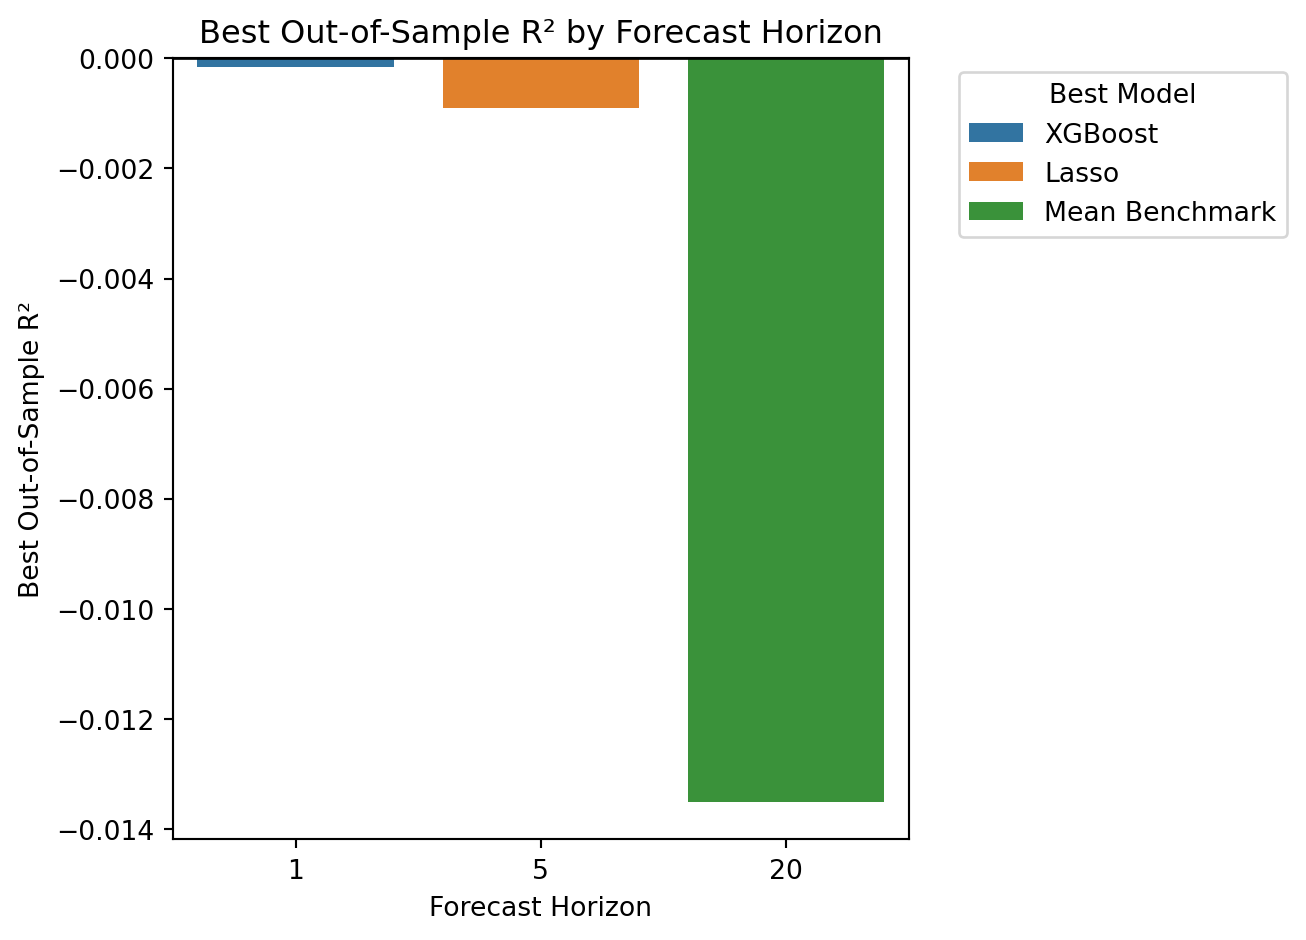

In [31]:
best_r2_by_horizon = (
    regression_results
    .sort_values(["Horizon", "R2"], ascending=[True, False])
    .groupby("Horizon")
    .first()
    .reset_index()
)

plt.figure(figsize=(7, 5))
sns.barplot(
    data=best_r2_by_horizon,
    x="Horizon",
    y="R2",
    hue="Model",
    dodge=False
)

plt.axhline(0, color="black", linewidth=1)
plt.title("Best Out-of-Sample R² by Forecast Horizon")
plt.xlabel("Forecast Horizon")
plt.ylabel("Best Out-of-Sample R²")
plt.legend(title="Best Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

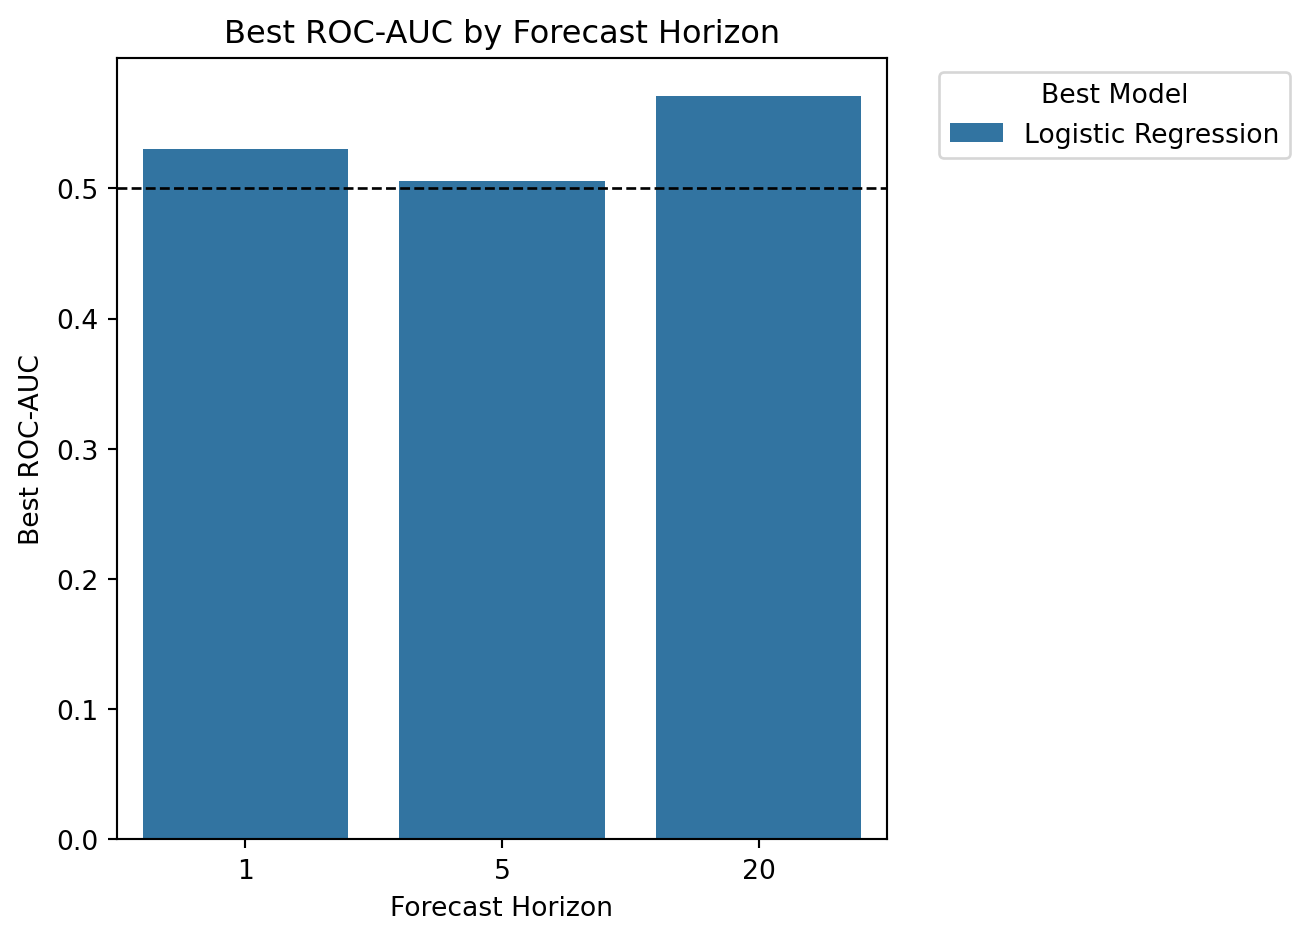

In [32]:
best_auc_by_horizon = (
    classification_results
    .dropna(subset=["ROC_AUC"])
    .sort_values(["Horizon", "ROC_AUC"], ascending=[True, False])
    .groupby("Horizon")
    .first()
    .reset_index()
)

plt.figure(figsize=(7, 5))
sns.barplot(
    data=best_auc_by_horizon,
    x="Horizon",
    y="ROC_AUC",
    hue="Model",
    dodge=False
)

plt.axhline(0.5, color="black", linestyle="--", linewidth=1)
plt.title("Best ROC-AUC by Forecast Horizon")
plt.xlabel("Forecast Horizon")
plt.ylabel("Best ROC-AUC")
plt.legend(title="Best Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

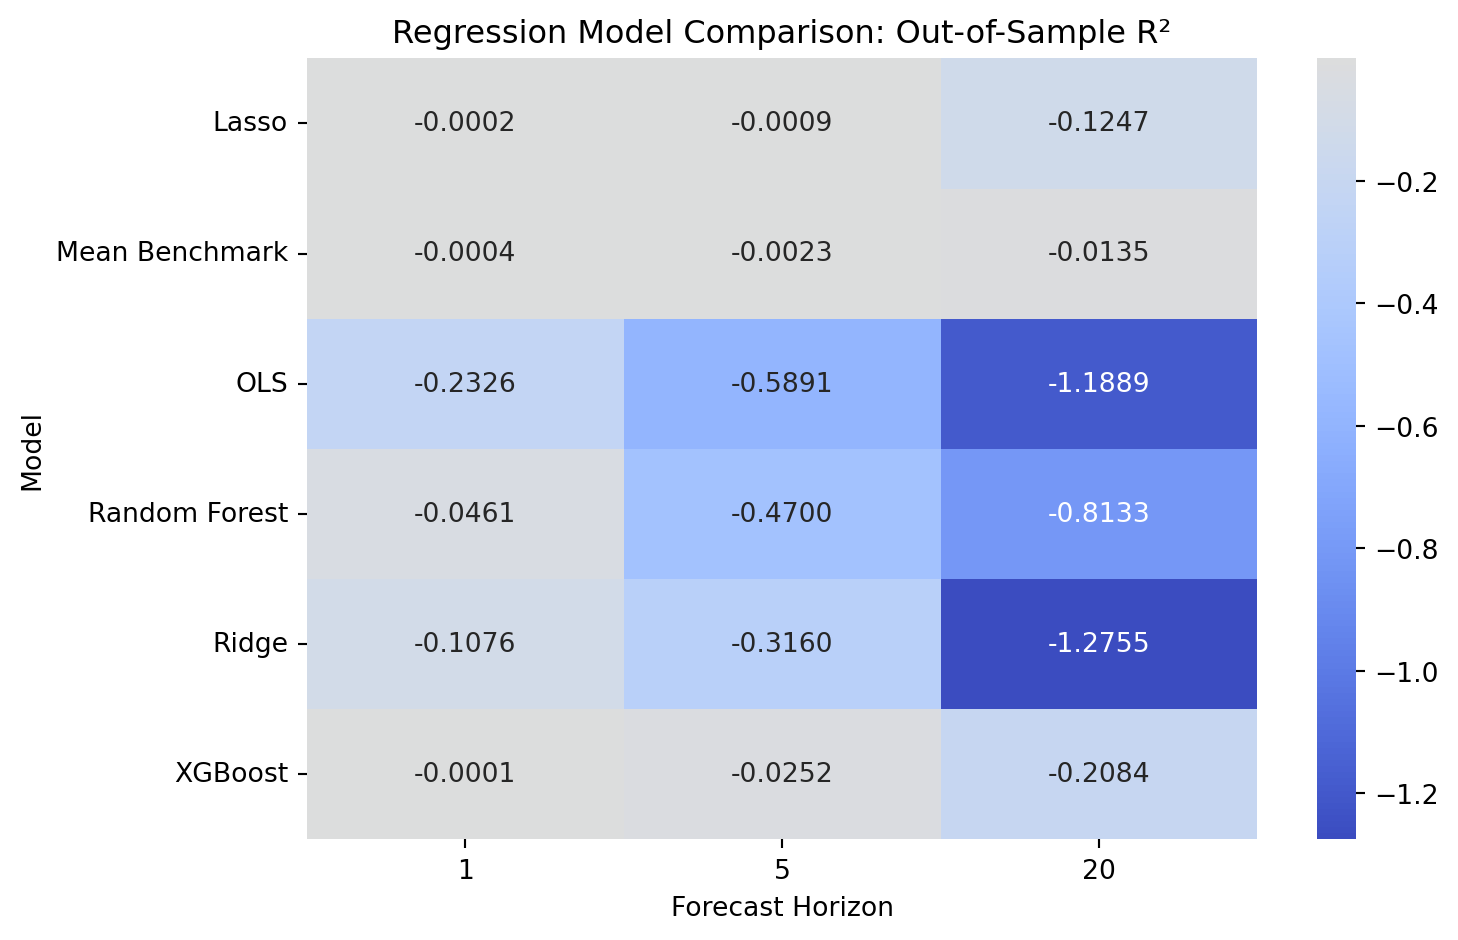

In [33]:
regression_r2_heatmap = regression_results.pivot(
    index="Model",
    columns="Horizon",
    values="R2"
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    regression_r2_heatmap,
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    center=0
)

plt.title("Regression Model Comparison: Out-of-Sample R²")
plt.xlabel("Forecast Horizon")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

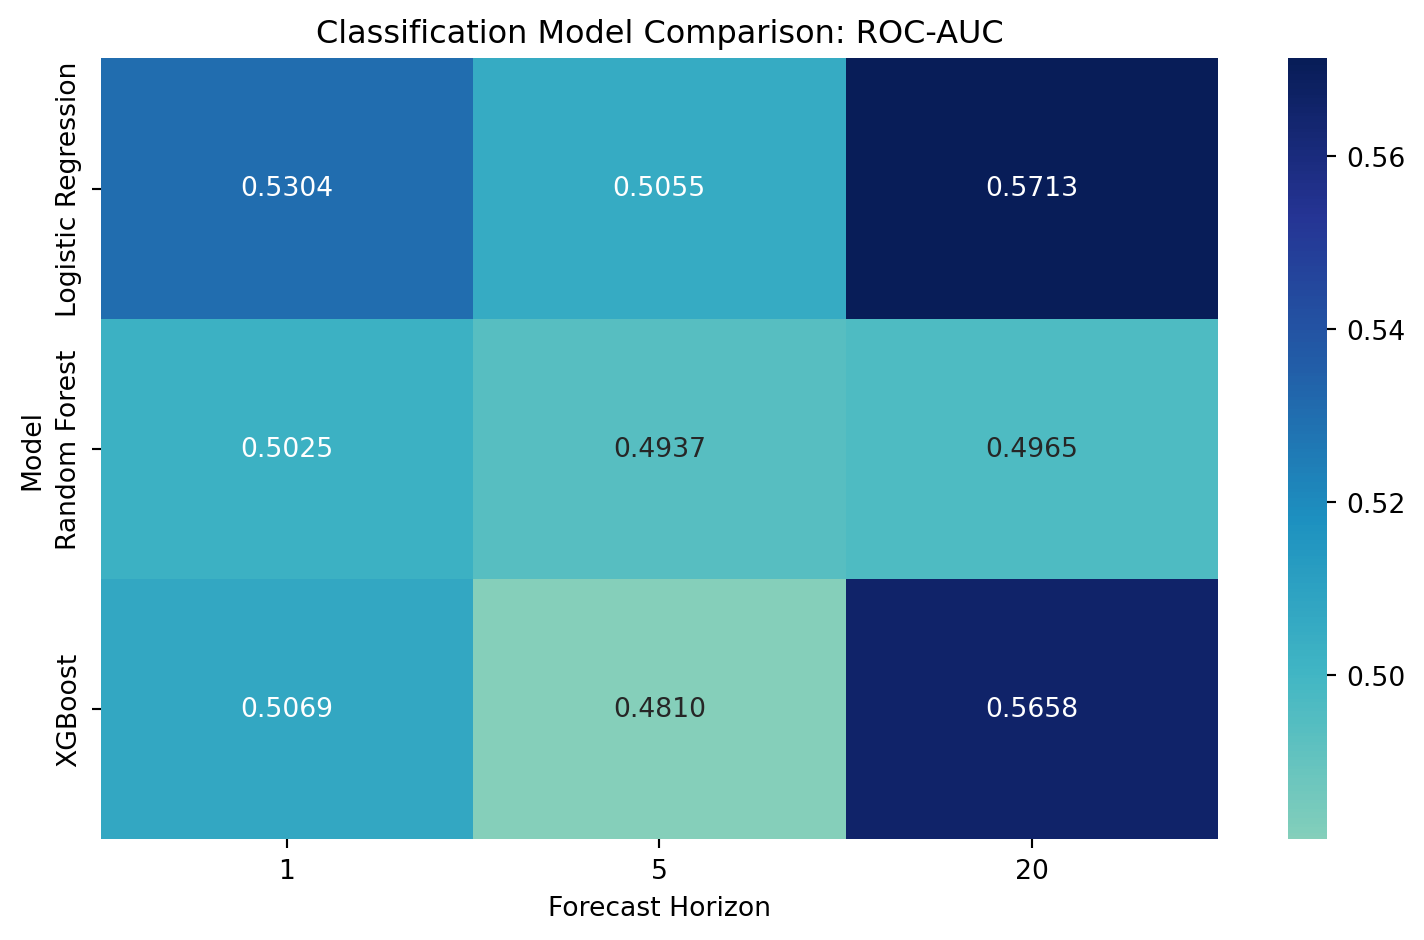

In [34]:
classification_auc_heatmap = (
    classification_results
    .dropna(subset=["ROC_AUC"])
    .pivot(
        index="Model",
        columns="Horizon",
        values="ROC_AUC"
    )
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    classification_auc_heatmap,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    center=0.5
)

plt.title("Classification Model Comparison: ROC-AUC")
plt.xlabel("Forecast Horizon")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

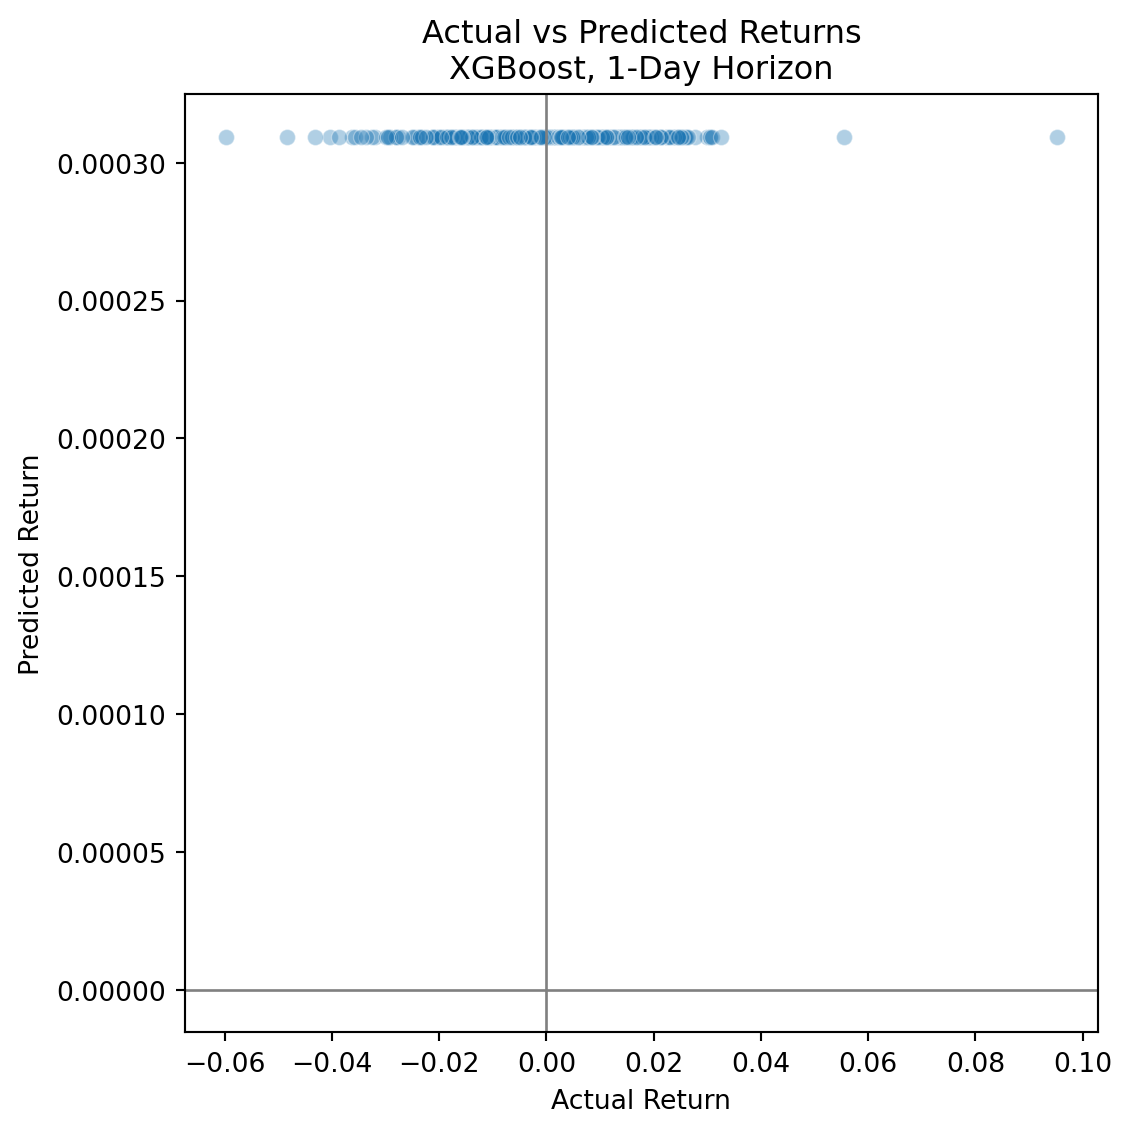

In [35]:
best_reg_row = (
    regression_results
    .sort_values("RMSE")
    .iloc[0]
)

best_reg_h = int(best_reg_row["Horizon"])
best_reg_model_name = best_reg_row["Model"]

best_pred = best_regression_predictions[(best_reg_h, best_reg_model_name)]
actual = test[f"sp500_return_t{best_reg_h}"]

pred_actual_df = pd.DataFrame({
    "Actual Return": actual.values,
    "Predicted Return": best_pred
})

plt.figure(figsize=(6, 6))
sns.scatterplot(
    data=pred_actual_df,
    x="Actual Return",
    y="Predicted Return",
    alpha=0.35
)

plt.axhline(0, color="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)

plt.title(f"Actual vs Predicted Returns\n{best_reg_model_name}, {best_reg_h}-Day Horizon")
plt.xlabel("Actual Return")
plt.ylabel("Predicted Return")
plt.tight_layout()
plt.show()

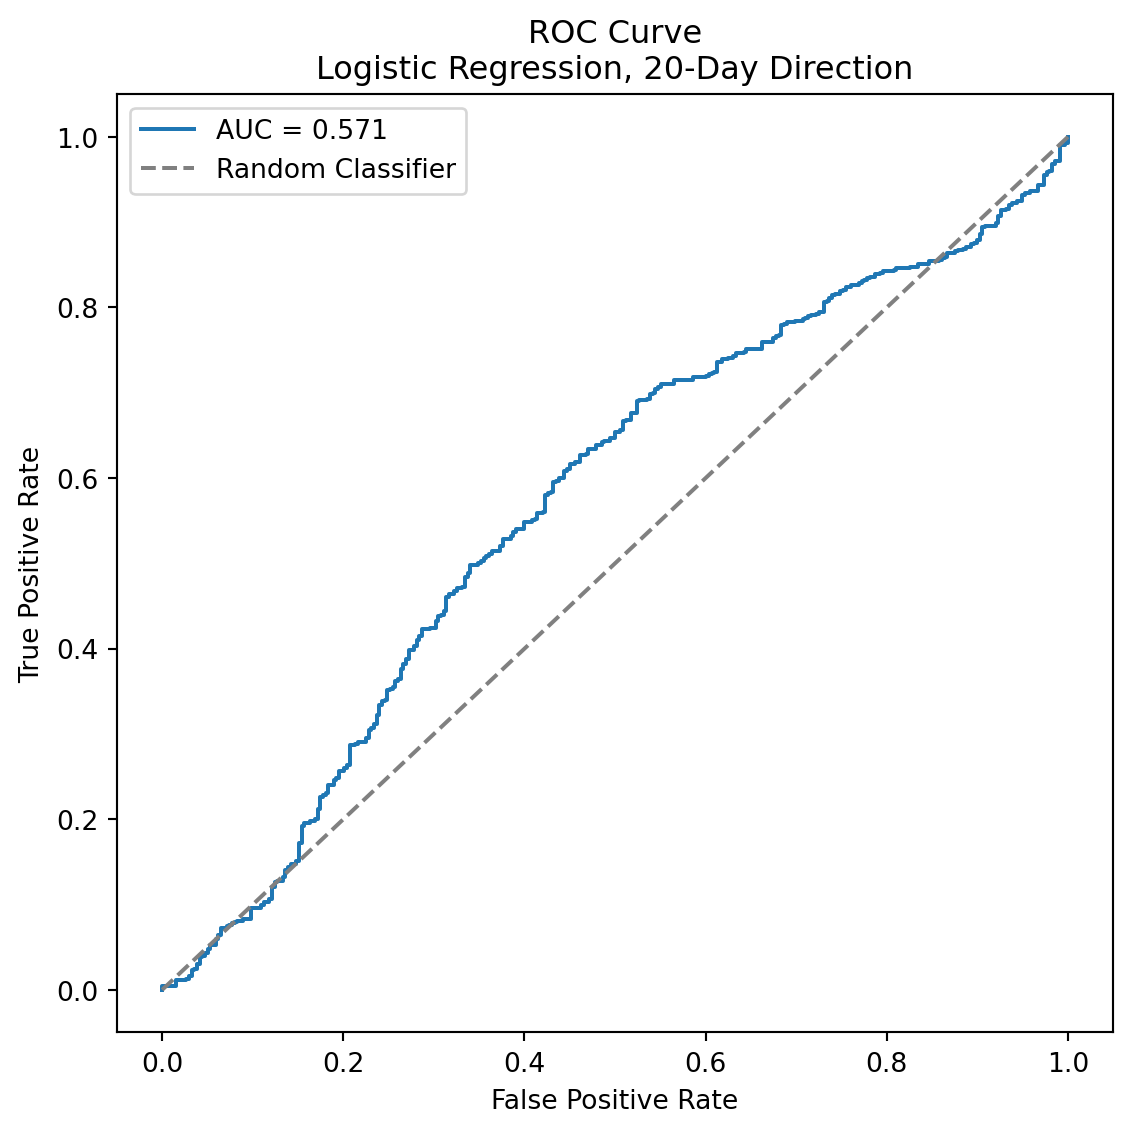

In [36]:
best_class_row = (
    classification_results
    .dropna(subset=["ROC_AUC"])
    .sort_values("ROC_AUC", ascending=False)
    .iloc[0]
)

best_class_h = int(best_class_row["Horizon"])
best_class_model_name = best_class_row["Model"]

y_true = test[f"sp500_up_t{best_class_h}"]
y_prob = best_classification_probabilities[(best_class_h, best_class_model_name)]

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")

plt.title(f"ROC Curve\n{best_class_model_name}, {best_class_h}-Day Direction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
def get_tree_importance(model, feature_cols, top_n=20):
    importance = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": model.feature_importances_
    })

    importance = (
        importance
        .sort_values("Importance", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    return importance


def plot_tree_importance(model, feature_cols, title, top_n=20):
    importance = get_tree_importance(model, feature_cols, top_n)

    plt.figure(figsize=(8, 6))
    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature"
    )

    plt.title(title)
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    return importance

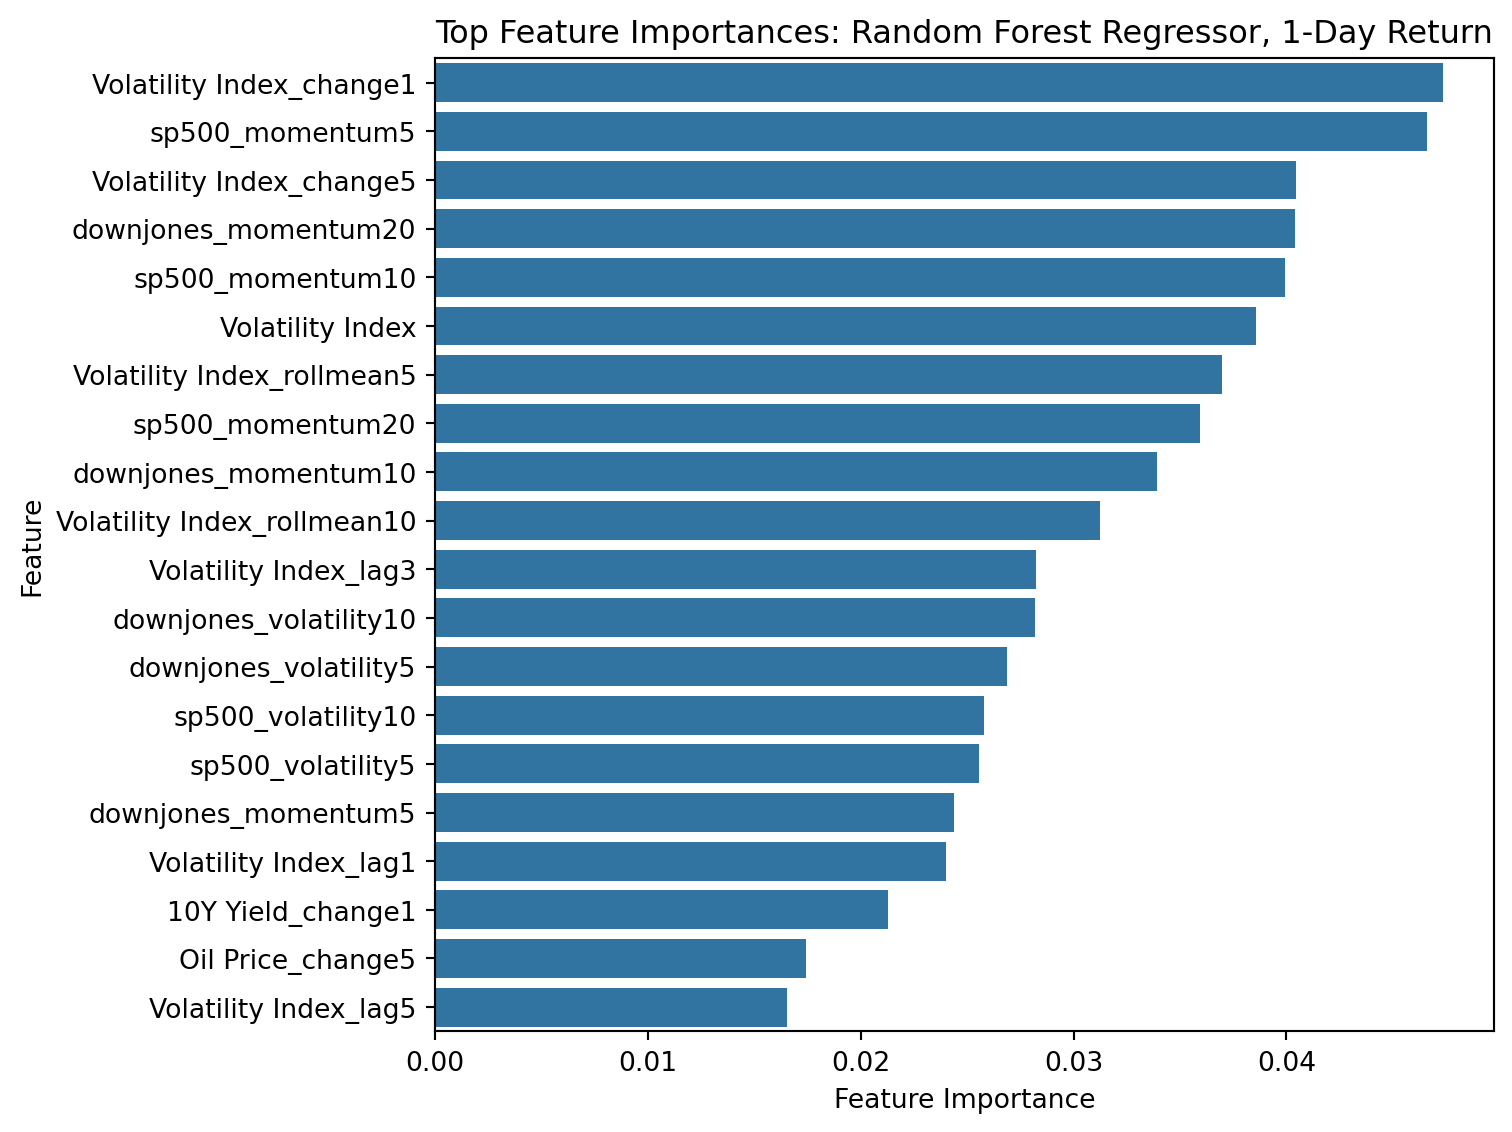

In [38]:
rf_reg_model = best_regression_models[(1, "Random Forest")]

rf_reg_importance = plot_tree_importance(
    rf_reg_model,
    feature_cols,
    title="Top Feature Importances: Random Forest Regressor, 1-Day Return",
    top_n=20
)

In [39]:
def get_logistic_coefficients(model, feature_cols, top_n=20):
    coef = model.named_steps["model"].coef_[0]

    coef_df = pd.DataFrame({
        "Feature": feature_cols,
        "Coefficient": coef,
        "Abs_Coefficient": np.abs(coef)
    })

    coef_df = (
        coef_df
        .sort_values("Abs_Coefficient", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    return coef_df


def plot_logistic_coefficients(model, feature_cols, title, top_n=20):
    coef_df = get_logistic_coefficients(model, feature_cols, top_n)

    plt.figure(figsize=(8, 6))
    sns.barplot(
        data=coef_df,
        x="Coefficient",
        y="Feature"
    )

    plt.axvline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("Standardized Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    return coef_df

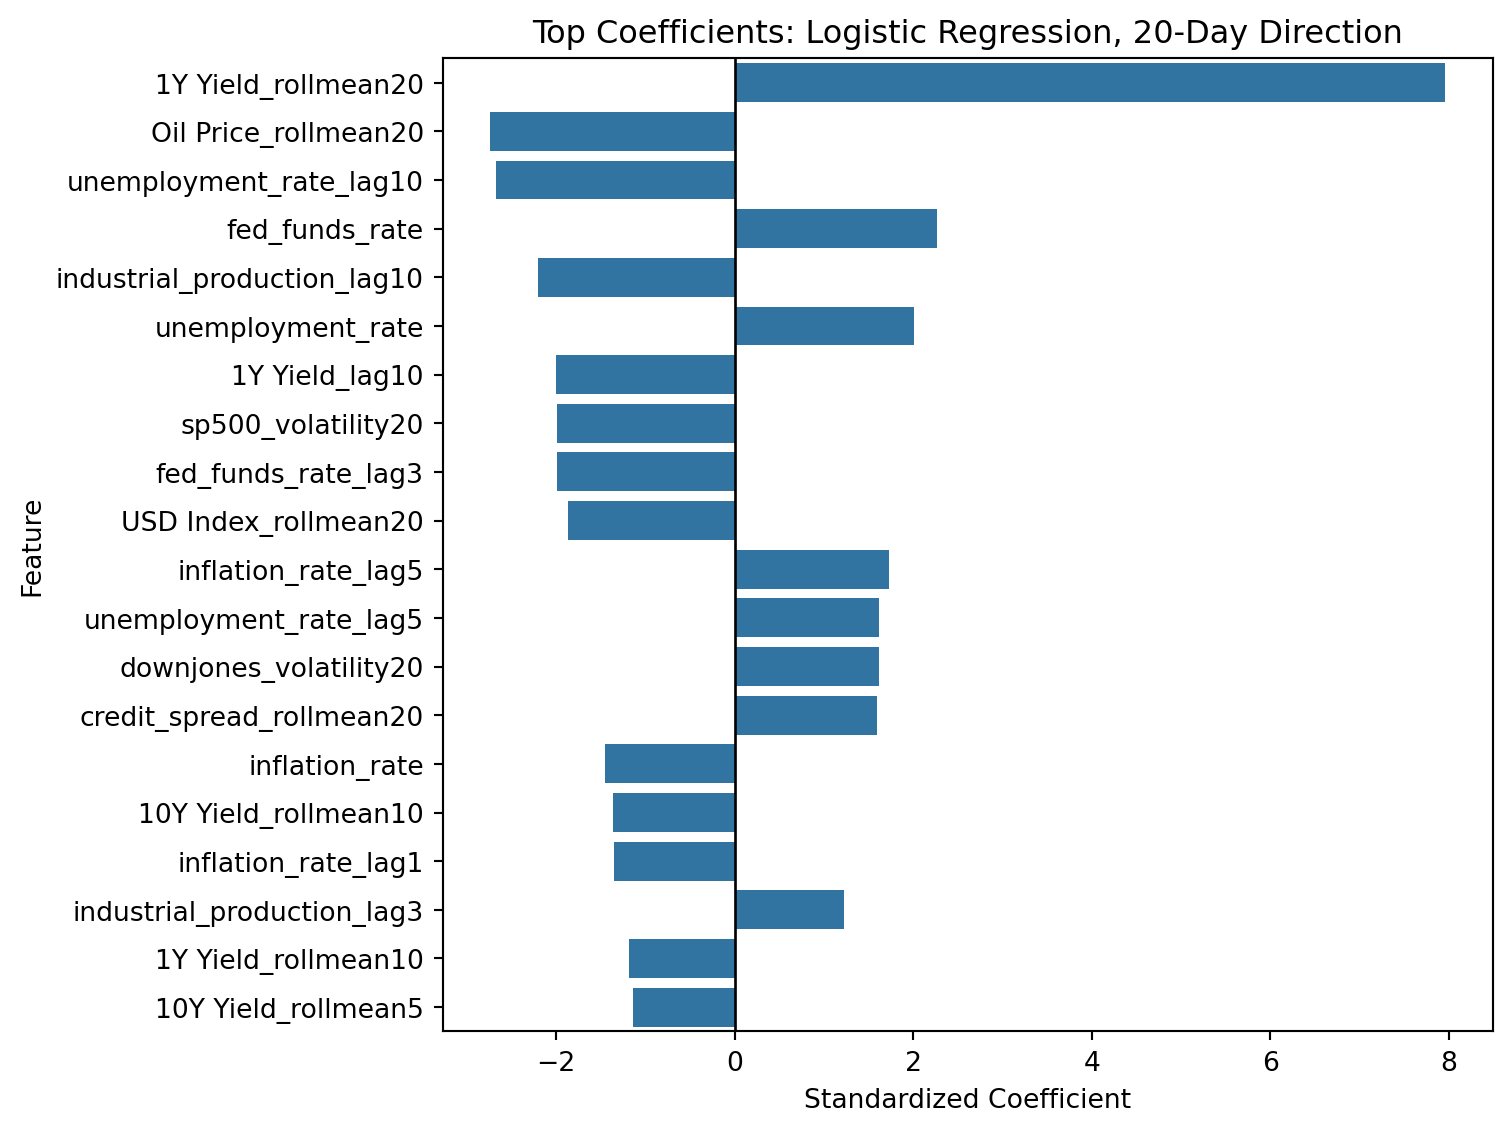

In [40]:
logit_model = best_classification_models[(20, "Logistic Regression")]

logit_coef_importance = plot_logistic_coefficients(
    logit_model,
    feature_cols,
    title="Top Coefficients: Logistic Regression, 20-Day Direction",
    top_n=20
)